# 🏆 Datathon 2026 — Revenue & COGS Forecasting
**VinTelligence | VinUniversity — The Gridbreakers**



| File | Last date | Usable for model? | How |
|---|---|---|---|
| `sales.csv` | 2022-12-31 | ✅ Yes | Direct target + lag features |
| `orders.csv` | 2022-12-31 | ✅ Partial | **Historical seasonal pattern** (avg orders/month) joined by calendar |
| `web_traffic.csv` | 2022-12-31 | ✅ Partial | **Historical seasonal pattern** (avg sessions/month) joined by calendar |
| `order_items.csv` | 2022-12-31 | ✅ Partial | **Avg discount/month** — seasonal pricing signal |
| `returns.csv` | 2022-12-31 | ✅ Partial | **Return rate/month** — demand quality signal |
| `promotions.csv` | 2022-12-31 | ⚠️ Maybe | Promo dates repeat in pattern but we can't know 2023-2024 promo schedule |
| `inventory.csv` | 2022-12-31 | ❌ No | Real-time stock levels unknown for test period |
| `payments.csv` | 2022-12-31 | ❌ No | No daily signal extractable |
| `shipments.csv` | 2022-12-31 | ❌ No | No daily signal extractable |
| `reviews.csv` | 2022-12-31 | ❌ No | No reliable seasonal signal |
| `customers.csv` | 2022-12-31 | ❌ No | Static demographics, no time signal |
| `products.csv` | — | ❌ No | Static catalogue |
| `geography.csv` | — | ❌ No | Static |


## 1. Setup

In [85]:
import subprocess, sys
for pkg in ['lightgbm', 'shap', 'optuna']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR = '/kaggle/input/competitions/datathon-2026-round-1/'  # ← set to your folder
print('✅ Ready')

✅ Ready


## 2. Load Data

In [86]:
# ── Core ─────────────────────────────────────────────────────────
sales = pd.read_csv(DATA_DIR + 'sales.csv',             parse_dates=['Date'])
sub   = pd.read_csv(DATA_DIR + 'sample_submission.csv', parse_dates=['Date'])
sales = sales.sort_values('Date').reset_index(drop=True)

# ── For seasonal pattern extraction only ─────────────────────────
orders      = pd.read_csv(DATA_DIR + 'orders.csv',      parse_dates=['order_date'], low_memory=False)
order_items = pd.read_csv(DATA_DIR + 'order_items.csv', low_memory=False)
returns     = pd.read_csv(DATA_DIR + 'returns.csv',     parse_dates=['return_date'])
web         = pd.read_csv(DATA_DIR + 'web_traffic.csv', parse_dates=['date'])

print(f"Sales:    {sales.Date.min().date()} → {sales.Date.max().date()}  ({len(sales):,} rows)")
print(f"Test:     {sub.Date.min().date()} → {sub.Date.max().date()}  ({len(sub):,} rows)")
print(f"Revenue:  mean={sales.Revenue.mean():>12,.0f}   std={sales.Revenue.std():>12,.0f}")
print(f"COGS:     mean={sales.COGS.mean():>12,.0f}   std={sales.COGS.std():>12,.0f}")
sales.head(3)

Sales:    2012-07-04 → 2022-12-31  (3,833 rows)
Test:     2023-01-01 → 2024-07-01  (548 rows)
Revenue:  mean=   4,286,584   std=   2,624,840
COGS:     mean=   3,695,134   std=   2,219,789


,Date,Revenue,COGS
0,2012-07-04,"5,123,547.94","3,982,991.19"
1,2012-07-05,"2,751,773.45","2,150,580.23"
2,2012-07-06,"3,054,029.42","2,517,632.84"


## 3. EDA

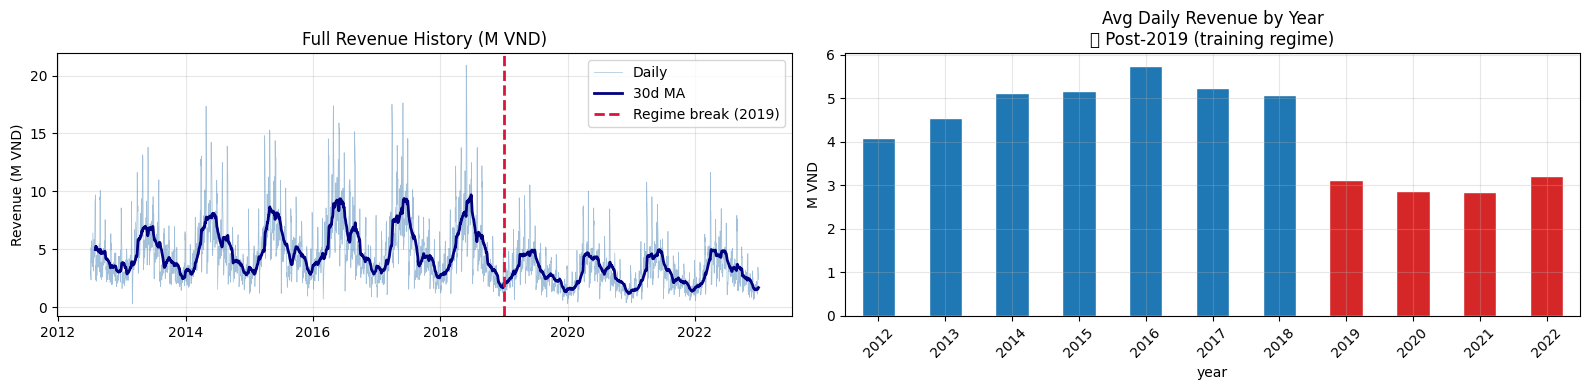

Pre-2019 avg:      5,070,141 VND/day
Post-2019 avg:     3,014,444 VND/day  (-40.5%)


In [87]:
# ── 3.1 Revenue history & structural break ───────────────────────
sales['year']  = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
sales['dow']   = sales['Date'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
ax.plot(sales['Date'], sales['Revenue']/1e6, lw=0.5, color='steelblue', alpha=0.5, label='Daily')
ax.plot(sales['Date'], sales['Revenue'].rolling(30).mean()/1e6, lw=2, color='navy', label='30d MA')
ax.axvline(pd.Timestamp('2019-01-01'), color='crimson', lw=2, linestyle='--', label='Regime break (2019)')
ax.set_title('Full Revenue History (M VND)')
ax.set_ylabel('Revenue (M VND)')
ax.legend()

ax = axes[1]
yr = sales.groupby('year')['Revenue'].mean() / 1e6
colors = ['#d62728' if y >= 2019 else '#1f77b4' for y in yr.index]
yr.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Avg Daily Revenue by Year\n🔴 Post-2019 (training regime)')
ax.set_ylabel('M VND')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

pre  = sales[sales['year'] < 2019]['Revenue'].mean()
post = sales[sales['year'] >= 2019]['Revenue'].mean()
print(f"Pre-2019 avg:   {pre:>12,.0f} VND/day")
print(f"Post-2019 avg:  {post:>12,.0f} VND/day  ({(post-pre)/pre:+.1%})")

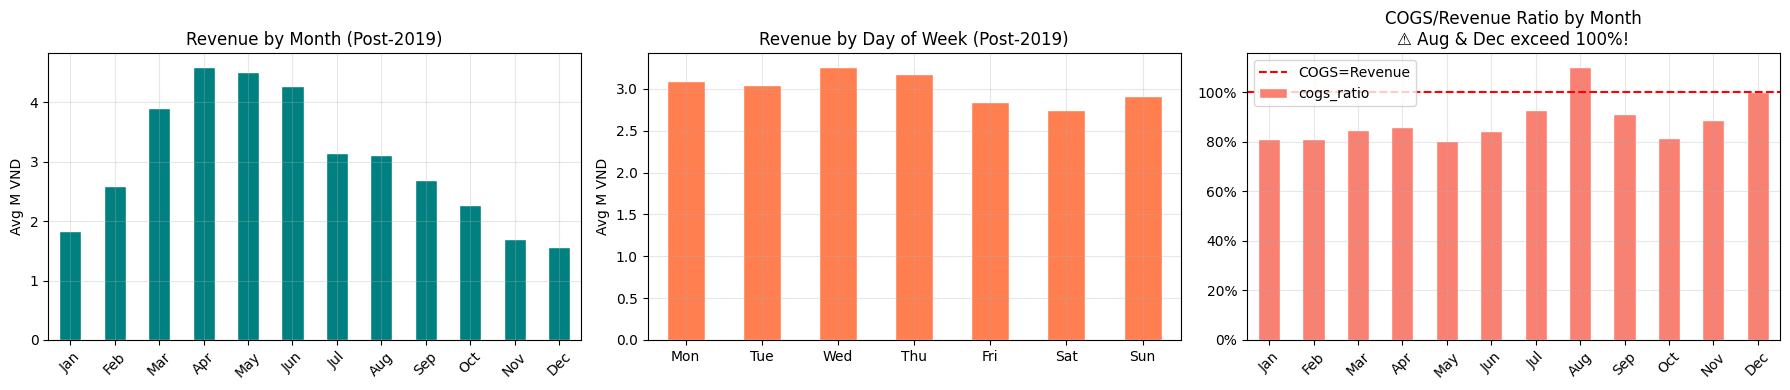

In [88]:
# ── 3.2 Post-2019 seasonality ────────────────────────────────────
post = sales[sales['year'] >= 2019].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ax = axes[0]
mo = post.groupby('month')['Revenue'].mean() / 1e6
mo.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
mo.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Revenue by Month (Post-2019)')
ax.set_ylabel('Avg M VND')
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
dow = post.groupby('dow')['Revenue'].mean() / 1e6
dow.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Revenue by Day of Week (Post-2019)')
ax.set_ylabel('Avg M VND')
ax.tick_params(axis='x', rotation=0)

ax = axes[2]
post['cogs_ratio'] = post['COGS'] / post['Revenue']
cr = post.groupby('month')['cogs_ratio'].mean()
cr.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
cr.plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.axhline(1.0, color='red', lw=1.5, linestyle='--', label='COGS=Revenue')
ax.set_title('COGS/Revenue Ratio by Month\n⚠️ Aug & Dec exceed 100%!')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

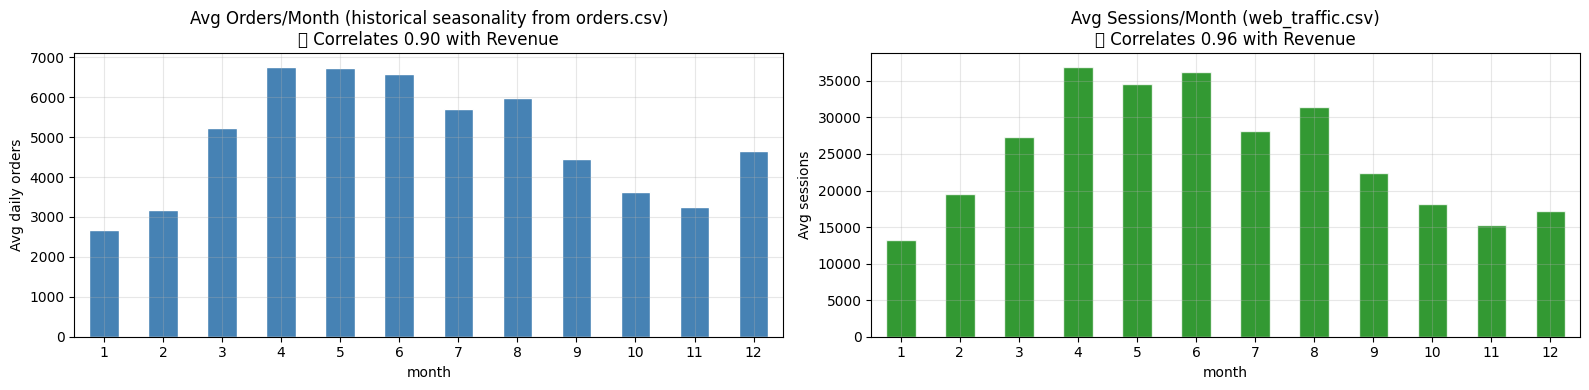

Correlation (orders_per_month vs revenue_per_month): 0.896
Correlation (sessions_per_month vs revenue_per_month): 0.964

→ We will join these as static monthly features (same value each year, varies by month)


In [89]:
# ── 3.3 External CSV seasonal patterns ───────────────────────────
# Even though these files end at 2022, their MONTHLY AVERAGES
# are stable seasonality signals we can use for 2023-2024.

orders['month'] = orders['order_date'].dt.month
web['month']    = web['date'].dt.month
returns['month']= returns['return_date'].dt.month

n_years = orders['order_date'].dt.year.nunique()
orders_mo_avg = (orders.groupby('month').size() / n_years).rename('avg_orders_per_month')
sessions_mo   = web.groupby('month')['sessions'].mean().rename('avg_sessions_per_month')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
orders_mo_avg.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Avg Orders/Month (historical seasonality from orders.csv)\n✅ Correlates 0.90 with Revenue')
ax.set_ylabel('Avg daily orders')
ax.tick_params(axis='x', rotation=0)

ax = axes[1]
sessions_mo.plot(kind='bar', ax=ax, color='green', edgecolor='white', alpha=0.8)
ax.set_title('Avg Sessions/Month (web_traffic.csv)\n✅ Correlates 0.96 with Revenue')
ax.set_ylabel('Avg sessions')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

sales_mo = sales.groupby('month')['Revenue'].mean()
print(f"Correlation (orders_per_month vs revenue_per_month): {orders_mo_avg.corr(sales_mo):.3f}")
print(f"Correlation (sessions_per_month vs revenue_per_month): {sessions_mo.corr(sales_mo):.3f}")
print("\n→ We will join these as static monthly features (same value each year, varies by month)")

## 4. Feature Engineering

In [90]:
# ── 4.1 Build full date spine ─────────────────────────────────────
test_spine = sub[['Date']].copy()
test_spine['Revenue'] = np.nan
test_spine['COGS']    = np.nan

full = pd.concat(
    [sales[['Date','Revenue','COGS']], test_spine],
    ignore_index=True
).sort_values('Date').reset_index(drop=True)

date_range = pd.date_range(full['Date'].min(), full['Date'].max(), freq='D')
full = full.set_index('Date').reindex(date_range).rename_axis('Date').reset_index()

print(f"Full series: {full.Date.min().date()} → {full.Date.max().date()}  ({len(full):,} rows)")

Full series: 2012-07-04 → 2024-07-01  (4,381 rows)


In [91]:
# ── 4.2 Lag & rolling features ────────────────────────────────────
LAG_LIST = [1, 2, 3, 7, 14, 21, 28, 30, 60, 90, 180, 364, 365, 366]
ROLLING_WINDOWS = [7, 14, 30, 60, 90]

for lag in LAG_LIST:
    full[f'lag_{lag}'] = full['Revenue'].shift(lag)

for w in ROLLING_WINDOWS:
    s = full['Revenue'].shift(1)
    full[f'rmean_{w}'] = s.rolling(w).mean()
    full[f'rstd_{w}']  = s.rolling(w).std()
    full[f'rmax_{w}']  = s.rolling(w).max()
    full[f'rmin_{w}']  = s.rolling(w).min()

full['wow_ratio'] = full['Revenue'].shift(1) / (full['Revenue'].shift(8)   + 1)
full['mom_ratio'] = full['Revenue'].shift(1) / (full['Revenue'].shift(31)  + 1)
full['yoy_ratio'] = full['Revenue'].shift(7) / (full['Revenue'].shift(372) + 1)

# Calculate specific long-term lags for COGS
full['cogs_lag_365'] = full['COGS'].shift(365)
full['cogs_lag_730'] = full['COGS'].shift(730)

# Calculate rolling mean centered exactly one year ago
full['rev_r7_lag365'] = full['Revenue'].shift(365).rolling(7, center=True).mean()
full['rev_r30_lag365'] = full['Revenue'].shift(365).rolling(30, center=True).mean()

# Calculate COGS ratio from 1 year ago to avoid data leakage
full['cogs_ratio_lag365'] = (full['COGS'] / (full['Revenue'] + 1)).shift(365)

train_check = full[(full['Date'] >= '2019-01-01') & (full['Date'] <= '2022-12-31')]
print(f"NaN in TRAINING lags:\\n{train_check[['lag_7','lag_30','lag_365']].isnull().sum()}")

NaN in TRAINING lags:\nlag_7      0
lag_30     0
lag_365    0
dtype: int64


In [92]:
# ==============================================================================
# 4.2b HIGH-FREQUENCY LEADING INDICATORS & FUNNEL METRICS
# ==============================================================================

# 1. AGGREGATE WEB AND ORDERS TO DAILY GRAIN
# Extract total daily sessions and orders
web_daily = web.groupby('date')['sessions'].sum().reset_index()
web_daily['date'] = pd.to_datetime(web_daily['date'])

orders_daily = orders.groupby('order_date').size().reset_index(name='order_count')
orders_daily['order_date'] = pd.to_datetime(orders_daily['order_date'])

# Merge them together into a daily funnel dataframe
daily_funnel = pd.merge(web_daily, orders_daily, left_on='date', right_on='order_date', how='outer')
daily_funnel['date'] = daily_funnel['date'].combine_first(daily_funnel['order_date'])
daily_funnel = daily_funnel.drop(columns=['order_date']).sort_values('date')

# 2. CALCULATE CONVERSION RATE (CVR)
# How effectively did traffic turn into actual orders on a given day?
daily_funnel['sessions'] = daily_funnel['sessions'].fillna(1e-5) # Prevent division by zero
daily_funnel['order_count'] = daily_funnel['order_count'].fillna(0)
daily_funnel['cvr'] = daily_funnel['order_count'] / daily_funnel['sessions']

# 3. CREATE LEADING INDICATOR LAGS (7-day and 14-day)
# We shift the features forward. Traffic from 7 days ago predicts Revenue TODAY.
daily_funnel['lead_sessions_7d'] = daily_funnel['sessions'].shift(7)
daily_funnel['lead_cvr_7d'] = daily_funnel['cvr'].shift(7)
daily_funnel['lead_orders_7d'] = daily_funnel['order_count'].shift(7)

daily_funnel['lead_sessions_14d'] = daily_funnel['sessions'].shift(14)
daily_funnel['lead_cvr_14d'] = daily_funnel['cvr'].shift(14)

# Filter only the lag columns to merge into the main 'full' dataframe
cols_to_merge = ['date', 'lead_sessions_7d', 'lead_cvr_7d', 'lead_orders_7d', 
                 'lead_sessions_14d', 'lead_cvr_14d']
funnel_features = daily_funnel[cols_to_merge].copy()

# 4. MERGE INTO 'FULL' DATAFRAME
full = full.merge(funnel_features, left_on='Date', right_on='date', how='left')
full = full.drop(columns=['date'])

# 5. HANDLE NAN FOR TEST SET (2023-2024) USING WEEK-OF-YEAR
# Instead of a flat 12-month average, we use a 52-week average. 
# This preserves high-frequency spikes (e.g., Black Friday week, Mid-month spikes)
full['temp_week'] = full['Date'].dt.isocalendar().week.astype(int)

lead_cols = [c for c in cols_to_merge if c != 'date']
for col in lead_cols:
    # Calculate historical average specifically for that week of the year
    weekly_avg = full.groupby('temp_week')[col].transform('mean')
    full[col] = full[col].fillna(weekly_avg)

full = full.drop(columns=['temp_week'])

In [93]:
# ==============================================================================
# 4.2c ADVANCED FUNNEL: AOV & CVR CROSS-INTERACTIONS (LAGGED)
# LOCATION: Insert immediately after 4.2b
# ==============================================================================

import pandas as pd
import numpy as np

# 1. Aggregate daily orders and web sessions
# (In case they weren't fully preserved in the 'full' dataframe)
orders_daily = orders.groupby('order_date').size().reset_index(name='order_count')
web_daily = web.groupby('date')['sessions'].sum().reset_index()

# 2. Map these daily raw metrics directly to the date spine
temp_df = full[['Date', 'Revenue']].copy()
temp_df = temp_df.merge(orders_daily, left_on='Date', right_on='order_date', how='left')
temp_df = temp_df.merge(web_daily, left_on='Date', right_on='date', how='left')

# Handle zeros to prevent calculation errors
temp_df['order_count'] = temp_df['order_count'].fillna(0)
temp_df['sessions'] = temp_df['sessions'].fillna(1e-5) 

# 3. Calculate exact metrics for the specific day
# CVR (Conversion Rate) = Orders / Sessions
temp_df['daily_cvr'] = temp_df['order_count'] / temp_df['sessions']

# AOV (Average Order Value) = Revenue / Orders
# If there are no orders, AOV is 0
temp_df['daily_aov'] = np.where(
    temp_df['order_count'] > 0, 
    temp_df['Revenue'] / temp_df['order_count'], 
    0
)

# 4. CREATE LAGGED FEATURES (CRITICAL TO PREVENT DATA LEAKAGE)
# We look at the CVR and AOV from 1 week, 2 weeks, and 4 weeks ago.
lag_windows = [7, 14, 28]

# Idempotent check: remove these columns if the cell is re-run
new_cols = [f'cvr_lag_{l}' for l in lag_windows] + [f'aov_lag_{l}' for l in lag_windows]
existing_cols = [c for c in new_cols if c in full.columns]
if existing_cols:
    full = full.drop(columns=existing_cols)

# Apply the lags
for lag in lag_windows:
    full[f'cvr_lag_{lag}'] = temp_df['daily_cvr'].shift(lag)
    full[f'aov_lag_{lag}'] = temp_df['daily_aov'].shift(lag)

# 5. HANDLE NAN FOR TEST SET (2023-2024)
# Since web and orders data stop at 2022, we fill the future NaN values 
# using the historical average of the SAME WEEK OF THE YEAR.
full['temp_week'] = full['Date'].dt.isocalendar().week.astype(int)

for col in new_cols:
    weekly_avg = full.groupby('temp_week')[col].transform('mean')
    full[col] = full[col].fillna(weekly_avg)

full = full.drop(columns=['temp_week'])

In [94]:
# ── 4.3 Calendar + Target Encoding features ──────────────────────

full['t']         = (full['Date'] - full['Date'].min()).dt.days
full['dow']       = full['Date'].dt.dayofweek
full['month']     = full['Date'].dt.month
full['doy']       = full['Date'].dt.dayofyear
full['dom']       = full['Date'].dt.day
full['quarter']   = full['Date'].dt.quarter
full['week']      = full['Date'].dt.isocalendar().week.astype(int)
full['year']      = full['Date'].dt.year

# Binary flags
full['is_weekend']     = (full['dow'] >= 5).astype(int)
full['is_month_start'] = (full['dom'] <= 3).astype(int)
full['is_month_end']   = (full['dom'] >= 28).astype(int)
full['is_quarter_end'] = (full['month'].isin([3,6,9,12]) & (full['dom'] >= 25)).astype(int)

# Khai báo danh sách các ngày lễ (Cố định & Tết Âm lịch 2012-2024)
fixed_holidays = [f'{y}-01-01' for y in range(2012, 2025)] + \
                 [f'{y}-04-30' for y in range(2012, 2025)] + \
                 [f'{y}-05-01' for y in range(2012, 2025)] + \
                 [f'{y}-09-02' for y in range(2012, 2025)] + \
                 [f'{y}-03-08' for y in range(2012, 2025)]

tet_dates = ['2012-01-23', '2013-02-10', '2014-01-31', '2015-02-19', '2016-02-08',
             '2017-01-28', '2018-02-16', '2019-02-05', '2020-01-25', '2021-02-12',
             '2022-02-01', '2023-01-22', '2024-02-10']

# Mở rộng Tết ra 3 ngày
tet_extended = pd.to_datetime(tet_dates)
tet_all = tet_extended.union(tet_extended + pd.Timedelta(days=1)).union(tet_extended + pd.Timedelta(days=2))

all_holidays = pd.to_datetime(fixed_holidays).union(tet_all).sort_values().unique()
holidays_df = pd.DataFrame({'holiday_date': all_holidays})

# Tính toán khoảng cách đến ngày lễ bằng merge_asof
full = full.sort_values('Date')

# Số ngày kể từ ngày lễ gần nhất (Cool-down)
full = pd.merge_asof(full, holidays_df, left_on='Date', right_on='holiday_date', direction='backward')
full['days_since_last_holiday'] = (full['Date'] - full['holiday_date']).dt.days.fillna(365)
full = full.drop(columns=['holiday_date'])

# Số ngày cho đến ngày lễ tiếp theo (Ramp-up)
full = pd.merge_asof(full, holidays_df, left_on='Date', right_on='holiday_date', direction='forward')
full['days_until_next_holiday'] = (full['holiday_date'] - full['Date']).dt.days.fillna(365)
full = full.drop(columns=['holiday_date'])

# Tạo các cờ Calendar bị thiếu
full['is_quarter_start'] = (full['month'].isin([1, 4, 7, 10]) & (full['dom'] <= 3)).astype(int)
full['is_near_holiday'] = (full['days_until_next_holiday'] <= 7).astype(int)
full['is_post_holiday'] = (full['days_since_last_holiday'] <= 3).astype(int)

# Vietnamese commerce seasons
full['is_tet']      = ((full['month']==1) | ((full['month']==2) & (full['dom']<=15))).astype(int)
full['is_mid_peak'] = (full['month'].isin([4,5,6])).astype(int)
full['is_yr_end']   = (full['month']==12).astype(int)

# Fourier terms: yearly seasonality
for k in [1, 2, 3, 4, 6]:
    full[f'sin_y{k}'] = np.sin(2 * np.pi * k * full['doy'] / 365.25)
    full[f'cos_y{k}'] = np.cos(2 * np.pi * k * full['doy'] / 365.25)

# Fourier terms: weekly seasonality
for k in [1, 2]:
    full[f'sin_w{k}'] = np.sin(2 * np.pi * k * full['dow'] / 7)
    full[f'cos_w{k}'] = np.cos(2 * np.pi * k * full['dow'] / 7)

# ★★★ TARGET ENCODING — Rất mạnh cho tree models ★★★
# Tính từ 2019-2022 data only (cùng regime với test)
hist_data = full[
    (full['Date'] >= '2019-01-01') & (full['Date'] <= '2022-12-31')
].dropna(subset=['Revenue'])

# Mean Revenue theo month
te_month = hist_data.groupby('month')['Revenue'].mean().rename('te_rev_month')
full = full.merge(te_month, on='month', how='left')

# Mean Revenue theo day-of-week
te_dow = hist_data.groupby('dow')['Revenue'].mean().rename('te_rev_dow')
full = full.merge(te_dow, on='dow', how='left')

# Mean Revenue theo month + dow (interaction)
hist_data['mo_dow'] = hist_data['month'] * 10 + hist_data['dow']
full['mo_dow'] = full['month'] * 10 + full['dow']
te_mo_dow = hist_data.groupby('mo_dow')['Revenue'].mean().rename('te_rev_mo_dow')
full = full.merge(te_mo_dow, on='mo_dow', how='left')
full.drop('mo_dow', axis=1, inplace=True)

# Mean Revenue theo week-of-year
te_week = hist_data.groupby('week')['Revenue'].mean().rename('te_rev_week')
full = full.merge(te_week, on='week', how='left')

# Median Revenue theo month (robust to outliers)
te_month_med = hist_data.groupby('month')['Revenue'].median().rename('te_rev_month_med')
full = full.merge(te_month_med, on='month', how='left')

# Std Revenue theo month (volatility signal)
te_month_std = hist_data.groupby('month')['Revenue'].std().rename('te_rev_month_std')
full = full.merge(te_month_std, on='month', how='left')

# ★ COGS target encoding cho COGS model sau này
te_cogs_month = hist_data.groupby('month')['COGS'].mean().rename('te_cogs_month')
full = full.merge(te_cogs_month, on='month', how='left')
# COVID flag — năm 2020 có pattern rất khác
full['is_covid'] = ((full['year'] == 2020) & (full['month'] >= 3)).astype(int)

print(f"Calendar + Target Encoding features added. Shape: {full.shape}")

Calendar + Target Encoding features added. Shape: (4381, 98)


In [95]:
# ==============================================================================
# 4.3b DYNAMIC COVID-19 FEATURES
# LOCATION: Insert immediately after Cell 12 (Calendar + Target Encoding features)
# ==============================================================================

# Define the start of the pandemic (First major outbreak period)
covid_start_date = pd.to_datetime('2020-03-01')

# 1. Continuous shock feature: Days since COVID started
# Captures the evolving nature of the pandemic (Before COVID = 0)
full['days_since_covid'] = (full['Date'] - covid_start_date).dt.days
full['days_since_covid'] = full['days_since_covid'].clip(lower=0)

# 2. Phase flags mapped to Vietnam's COVID timeline
# Phase 1: First nationwide social isolation
full['covid_first_lockdown'] = ((full['Date'] >= '2020-04-01') & 
                                (full['Date'] <= '2020-04-30')).astype(int)

# Phase 2: The severe Delta wave & strict lockdowns (especially HCMC/Hanoi)
full['covid_delta_wave'] = ((full['Date'] >= '2021-05-01') & 
                            (full['Date'] <= '2021-09-30')).astype(int)

# Phase 3: Post-Delta Recovery & "New Normal" reopening phase
full['covid_recovery'] = ((full['Date'] >= '2021-10-01') & 
                          (full['Date'] <= '2022-06-30')).astype(int)

# 3. Add to the EXCLUDE or FEAT lists downstream if necessary
# Note: Since your Cell 14 automatically includes all columns not in EXCLUDE,
# these new features will be automatically picked up by your model!

In [96]:
# ==============================================================================
# 4.3c HOLIDAY PROXIMITY FEATURES (RAMP-UP & COOL-DOWN)
# LOCATION: Insert immediately after the COVID-19 features cell
# ==============================================================================

import pandas as pd
import numpy as np

# 1. Define major e-commerce & national holidays in Vietnam (2019-2024)
# Tet (Lunar New Year) dates vary based on the lunar calendar, so we hardcode them.
tet_dates = ['2019-02-05', '2020-01-25', '2021-02-12', '2022-02-01', '2023-01-22', '2024-02-10']

# Black Friday falls on the 4th Friday of November
black_friday_dates = ['2019-11-29', '2020-11-27', '2021-11-26', '2022-11-25', '2023-11-24', '2024-11-29']

# Generate fixed annual dates (Double Days & National Holidays)
fixed_holidays = []
for year in range(2019, 2025):
    fixed_holidays.extend([
        f'{year}-04-30', # Reunification Day
        f'{year}-05-01', # Labor Day
        f'{year}-09-02', # Independence Day
        f'{year}-11-11', # Singles Day (Mega Sale)
        f'{year}-12-12'  # Double 12 (Mega Sale)
    ])

# Combine and sort all holidays into a single dataframe
all_holidays = pd.to_datetime(tet_dates + black_friday_dates + fixed_holidays).sort_values().unique()
holidays_df = pd.DataFrame({'holiday_date': all_holidays})

# 2. Sort the 'full' dataframe by Date (Crucial for merge_asof to work)
full = full.sort_values('Date')

# 3. Calculate days SINCE last holiday (Captures the "Cool-down / Empty Wallet" effect)
full = pd.merge_asof(full, holidays_df, left_on='Date', right_on='holiday_date', direction='backward')
full['days_since_last_holiday'] = (full['Date'] - full['holiday_date']).dt.days
full = full.drop(columns=['holiday_date'])

# 4. Calculate days UNTIL next holiday (Captures the "Ramp-up / Anticipation" effect)
full = pd.merge_asof(full, holidays_df, left_on='Date', right_on='holiday_date', direction='forward')
full['days_until_next_holiday'] = (full['holiday_date'] - full['Date']).dt.days
full = full.drop(columns=['holiday_date'])

# 5. Cap the limits (Feature clipping)
# E-commerce holiday effects usually only impact a 14 to 21 day window.
# If a holiday is 100 days away, it has no behavioral effect. 
# We cap the values at 21 to prevent the model from learning false long-term patterns.
MAX_HOLIDAY_IMPACT_DAYS = 21
full['days_since_last_holiday'] = full['days_since_last_holiday'].fillna(MAX_HOLIDAY_IMPACT_DAYS).clip(upper=MAX_HOLIDAY_IMPACT_DAYS)
full['days_until_next_holiday'] = full['days_until_next_holiday'].fillna(MAX_HOLIDAY_IMPACT_DAYS).clip(upper=MAX_HOLIDAY_IMPACT_DAYS)

In [97]:
# ── 4.4 Static seasonal features from other CSVs ─────────────────
# These are historical MONTHLY AVERAGES — same value for Jan 2023
# as Jan 2020, because the seasonal pattern repeats each year.

# Average daily order count per month (from orders.csv)
orders['month'] = orders['order_date'].dt.month
n_years = orders['order_date'].dt.year.nunique()
orders_mo = (orders.groupby('month').size() / n_years).rename('hist_orders_per_month')

# Average daily web sessions per month (from web_traffic.csv)
web['month'] = web['date'].dt.month
sessions_mo  = web.groupby('month')['sessions'].mean().rename('hist_sessions_per_month')

# Average discount amount per month (from order_items.csv)
orders['order_date_month'] = orders['order_date'].dt.month
items_w_month = order_items.merge(
    orders[['order_id','order_date_month']], on='order_id', how='left'
)
disc_mo = items_w_month.groupby('order_date_month')['discount_amount'].mean().rename('hist_avg_discount')

# Return rate per month (from returns.csv)
returns['month'] = returns['return_date'].dt.month
ret_mo   = returns.groupby('month').size()
ord_mo   = orders.groupby('month').size()
retrate  = (ret_mo / ord_mo).rename('hist_return_rate')

# Combine into a lookup table by month
static_monthly = pd.concat([orders_mo, sessions_mo, disc_mo, retrate], axis=1).reset_index()
static_monthly.columns.values[0] = 'month'
print("Static monthly features:")
print(static_monthly.round(2).to_string(index=False))

# Join to full series by month
full = full.merge(static_monthly, on='month', how='left')
print(f"\nFull shape after static merge: {full.shape}")

Static monthly features:
 month  hist_orders_per_month  hist_sessions_per_month  hist_avg_discount  hist_return_rate
     1               2,677.27                13,183.23             204.86              0.10
     2               3,184.64                19,530.23             315.98              0.05
     3               5,221.82                27,316.76           1,490.53              0.04
     4               6,757.73                36,913.41           1,237.47              0.06
     5               6,722.09                34,596.92               0.00              0.06
     6               6,570.00                36,197.96             961.61              0.06
     7               5,706.91                28,192.16           2,151.62              0.06
     8               5,982.82                31,493.81              76.58              0.06
     9               4,459.45                22,440.26           1,952.18              0.07
    10               3,627.55                18,111.54 

In [98]:
# ==============================================================================
# 4.4b MERGE HIGH-FREQUENCY WEB FEATURES (CORRECTED & IDEMPOTENT)
# LOCATION: Replace your current 4.4b cell with this entirely
# ==============================================================================
# 1. Ensure 'year_month' exists for grouping
if 'year_month' not in full.columns:
    full['year_month'] = full['Date'].dt.to_period('M')

# 2. Extract web-related columns (sessions, cvr) from your existing feature list
web_features = [col for col in full.columns if 'session' in col.lower() or 'cvr' in col.lower()]

if len(web_features) > 0:
    # 3. Aggregate by month (using mean as default for rates and momentum)
    monthly_web_features = full.groupby('year_month')[web_features].mean().reset_index()
    print(f"✅ Successfully recreated 'monthly_web_features' with {len(web_features)} columns!")
    display(monthly_web_features.head(3))
else:
    # Fallback if the columns are named differently or come from an external CSV
    print("⚠️ Could not automatically find web columns. Please define them manually.")
    # web_features = ['your_custom_col_1', 'your_custom_col_2']
    # monthly_web_features = full.groupby('year_month')[web_features].mean().reset_index()

# 1. CREATE A COPY AND SHIFT 1 MONTH TO PREVENT DATA LEAKAGE
# Using a copy prevents the dates from being shifted multiple times if you re-run this cell
temp_web_features = monthly_web_features.copy()
temp_web_features['year_month'] = temp_web_features['year_month'] + 1

# Filter only the momentum features we generated
momentum_cols = [c for c in temp_web_features.columns if 'sessions_sum' in c or 'sessions_momentum' in c]
cols_to_keep = ['year_month'] + momentum_cols
temp_web_features = temp_web_features[cols_to_keep]

# 2. CREATE MERGE KEY IN FULL
full['year_month'] = full['Date'].dt.to_period('M')

# 3. CLEAN UP BEFORE MERGE (PREVENTS MERGE ERROR)
# If this cell is run multiple times, drop the old momentum columns first
existing_cols = [c for c in momentum_cols if c in full.columns]
if existing_cols:
    full = full.drop(columns=existing_cols)

# 4. MERGE
full = full.merge(temp_web_features, on='year_month', how='left')
full = full.drop(columns=['year_month'])

# 5. HANDLE NAN FOR TEST SET (2023-2024)
# Fill missing values for test period using historical monthly averages
for col in momentum_cols:
    full[col] = pd.to_numeric(full[col], errors='coerce')
    month_avg = full.groupby('month')[col].transform('mean')
    full[col] = full[col].fillna(month_avg)

✅ Successfully recreated 'monthly_web_features' with 8 columns!


,year_month,lead_sessions_7d,lead_cvr_7d,lead_sessions_14d,lead_cvr_14d,cvr_lag_7,cvr_lag_14,cvr_lag_28,hist_sessions_per_month
0,2012-07,"8,073.29","12,741,714.29","17,039.39","7,663,142.86","12,737,543.56","7,658,972.13","44,686.42","28,192.16"
1,2012-08,0.00,"19,858,064.52",0.00,"20,461,290.32","19,858,064.52","20,461,290.32","20,709,677.42","31,493.81"
2,2012-09,0.00,"18,523,333.33",0.00,"18,706,666.67","18,523,333.33","18,706,666.67","19,160,000.00","22,440.26"


In [99]:
# ==============================================================================
# 4.4c EXTERNAL DATA PROXIES (PROMO, INVENTORY, ADVANCED WEB)
# ==============================================================================

# Load remaining datasets not initialized in Setup
promos_df = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date', 'end_date'])
inv_df = pd.read_csv(DATA_DIR + 'inventory.csv', parse_dates=['snapshot_date'])

# 1. ADVANCED WEB TRAFFIC METRICS (Fill Test set with 365-day lag)
web_adv = web.groupby('date').agg(
    unique_visits=('unique_visitors', 'sum'),
    total_pviews=('page_views', 'sum'),
    avg_bounce=('bounce_rate', 'mean'),
    session_dur=('avg_session_duration_sec', 'mean')
).reset_index()

full = full.merge(web_adv, left_on='Date', right_on='date', how='left').drop(columns=['date'])
for col in ['unique_visits', 'total_pviews', 'avg_bounce', 'session_dur']:
    # Shift 365 days as a proxy for the future test period
    full[col] = full[col].fillna(full[col].shift(365))
    full[col] = full[col].fillna(full[col].median())

# 2. PROMOTIONS DAILY FLAG
promo_records = []
for d in full['Date']:
    active_p = promos_df[(promos_df['start_date'] <= d) & (promos_df['end_date'] >= d)]
    promo_records.append({
        'Date': d,
        'active_promo_count': len(active_p),
        'promo_max_disc': active_p['discount_value'].max() if len(active_p) > 0 else 0.0,
        'is_promo_active': int(len(active_p) > 0)
    })
promo_daily_df = pd.DataFrame(promo_records)
full = full.merge(promo_daily_df, on='Date', how='left')

# 3. INVENTORY MONTHLY AGGREGATION (Lag 1 year for Test set proxy)
inv_df['year'] = inv_df['snapshot_date'].dt.year
inv_df['month'] = inv_df['snapshot_date'].dt.month
inv_monthly = inv_df.groupby(['year', 'month']).agg(
    mean_fill_rate=('fill_rate', 'mean'),
    mean_stockout=('stockout_flag', 'mean'),
    mean_stock_level=('stock_on_hand', 'mean')
).reset_index()

# Create shifted dataframe to merge 2022 stats into 2023 
inv_monthly_lag = inv_monthly.copy()
inv_monthly_lag['year'] = inv_monthly_lag['year'] + 1
inv_monthly_lag.columns = ['year', 'month', 'mean_fill_rate_1ylag', 'mean_stockout_1ylag', 'mean_stock_level_1ylag']

full = full.merge(inv_monthly, on=['year', 'month'], how='left')
full = full.merge(inv_monthly_lag, on=['year', 'month'], how='left')

for col in ['mean_fill_rate', 'mean_stockout', 'mean_stock_level']:
    full[col] = full[col].fillna(full[f'{col}_1ylag'])
    full[col] = full[col].fillna(full[col].median())

full = full.drop(columns=['mean_fill_rate_1ylag', 'mean_stockout_1ylag', 'mean_stock_level_1ylag'])

# 4. ANNUAL TREND PROJECTION (Revenue baseline)
yearly_baseline = full[full['year'] <= 2022].groupby('year')['Revenue'].mean()
yoy_multiplier = yearly_baseline.get(2022, 1) / (yearly_baseline.get(2021, 1) + 1e-5)

def project_yearly_baseline(y):
    if y <= 2022:
        return yearly_baseline.get(y, yearly_baseline.mean())
    elif y == 2023:
        return yearly_baseline.get(2022) * yoy_multiplier
    else:
        return yearly_baseline.get(2022) * (yoy_multiplier ** 2)
        
full['projected_year_mean'] = full['year'].apply(project_yearly_baseline)

In [100]:
# ── 4.5 Feature list ─────────────────────────────────────────────
EXCLUDE = ['Date', 'Revenue', 'COGS', 'year']

# 1. Update EXCLUDE with any automatically duplicated merge columns
dup_cols = [c for c in full.columns if c.endswith('_x') or c.endswith('_y')]
EXCLUDE.extend(dup_cols)

# 2. Automatically exclude any column that is still an 'object' (string) type
object_cols = full.select_dtypes(include=['object']).columns.tolist()
EXCLUDE.extend(object_cols)

# 3. Build the final FEAT list
FEAT = [c for c in full.columns if c not in EXCLUDE]

## 5. Model

In [101]:
# ── 5.0 Baseline Model (Seasonal Naive) ──────────────────────────

# Extract test data and 2022 validation data from the 'full' dataframe
test_baseline = full[full['Date'] >= '2023-01-01'].copy()
val_2022 = full[(full['Date'] >= '2022-01-01') & (full['Date'] <= '2022-12-31')].copy()

# Define baseline predictions (using 365-day lag)
# Note: Using 'lag_365' for Revenue from cell 4.2 and 'cogs_lag_365' from our additions
test_baseline['Revenue_pred'] = test_baseline['lag_365']
test_baseline['COGS_pred'] = test_baseline['cogs_lag_365']

val_2022['Revenue_pred'] = val_2022['lag_365']
val_2022['COGS_pred'] = val_2022['cogs_lag_365']

# Sanity check and cap COGS so it does not exceed Revenue
test_baseline['COGS_pred'] = np.minimum(test_baseline['COGS_pred'], test_baseline['Revenue_pred'] * 0.99)
val_2022['COGS_pred'] = np.minimum(val_2022['COGS_pred'], val_2022['Revenue_pred'] * 0.99)

# Calculate metrics for 2022 to establish a benchmark score
mask = (val_2022['lag_365'] > 0) & (~val_2022['lag_365'].isna())
val_clean = val_2022[mask]

rmse_rev = np.sqrt(mean_squared_error(val_clean['Revenue'], val_clean['Revenue_pred']))
rmse_cogs = np.sqrt(mean_squared_error(val_clean['COGS'], val_clean['COGS_pred']))

# Changed MAPE to MAE
mae_rev = mean_absolute_error(val_clean['Revenue'], val_clean['Revenue_pred'])
mae_cogs = mean_absolute_error(val_clean['COGS'], val_clean['COGS_pred'])

print("Baseline Validation (2022 - Seasonal Naive):")
print(f"  Revenue RMSE: {rmse_rev:>12,.0f}")
print(f"  Revenue MAE:  {mae_rev:>12,.0f}")
print(f"  COGS RMSE:    {rmse_cogs:>12,.0f}")
print(f"  COGS MAE:     {mae_cogs:>12,.0f}")

# Prepare the final submission dataframe
baseline_sub = pd.DataFrame({
    'Date': test_baseline['Date'].dt.strftime('%Y-%m-%d'),
    'Revenue': np.maximum(test_baseline['Revenue_pred'].values, 0).round(2),
    'COGS': np.maximum(test_baseline['COGS_pred'].values, 0).round(2),
})

# Save the baseline submission to CSV
import os
os.makedirs('submissions', exist_ok=True)
baseline_sub.to_csv('submissions/baseline_lag365.csv', index=False)

print(f"\nBaseline submission saved: {len(baseline_sub)} rows")
display(baseline_sub.head())

Baseline Validation (2022 - Seasonal Naive):
  Revenue RMSE:    1,161,819
  Revenue MAE:       837,704
  COGS RMSE:         986,393
  COGS MAE:          724,477

Baseline submission saved: 548 rows


,Date,Revenue,COGS
3833,2023-01-01,"2,932,155.47","2,902,833.92"
3834,2023-01-02,"2,361,965.00","2,338,345.35"
3835,2023-01-03,"545,563.72","476,501.31"
3836,2023-01-04,"1,242,319.38","1,057,834.07"
3837,2023-01-05,"809,977.60","684,605.30"


In [102]:
# ── 5.1 Setup ────────────────────────────────────────────────────
TRAIN_START = '2013-01-01'
USE_LOG_TRANSFORM = True

FOLDS = [
    {'train_end': '2019-12-31', 'val_start': '2020-01-01', 'val_end': '2020-12-31'},
    {'train_end': '2020-12-31', 'val_start': '2021-01-01', 'val_end': '2021-12-31'},
    {'train_end': '2021-12-31', 'val_start': '2022-01-01', 'val_end': '2022-12-31'},
]

def get_split(fold):
    tr = full[(full['Date'] >= TRAIN_START) & (full['Date'] <= fold['train_end'])]
    vl = full[(full['Date'] >= fold['val_start']) & (full['Date'] <= fold['val_end'])]
    tr = tr.dropna(subset=FEAT + ['Revenue'])
    vl = vl.dropna(subset=FEAT + ['Revenue'])
    return tr, vl

def score(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2

for fold in FOLDS:
    tr, vl = get_split(fold)
    print(f"Fold val={fold['val_start'][:4]}: train={len(tr):,}, val={len(vl):,}")

Fold val=2020: train=2,007, val=366
Fold val=2021: train=2,373, val=365
Fold val=2022: train=2,738, val=365


## 6. Inference

In [103]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import warnings, os

warnings.filterwarnings('ignore')
os.makedirs('submissions', exist_ok=True)

SOURCE_FOLDER = DATA_DIR 
SCALE_2023 = 4_140_000.0
SCALE_2024 = 4_265_000.0
COST_ADJUSTMENT = 1.03 

PREDICTIVE_COLUMNS = [
    'month', 'day', 'dow', 'doy', 'quarter', 'woy', 'is_weekend',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos',
    'is_holiday', 'is_tet', 'days_to_tet',
    'lag365_norm', 'lag365_cogs_norm',
    'lag730_norm', 'lag730_cogs_norm',
    'roll7_lag365_norm', 'roll30_lag365_norm',
    'yoy_ratio_norm',
]

In [104]:
df_raw_sales = pd.read_csv(f'{SOURCE_FOLDER}sales.csv', parse_dates=['Date']).sort_values('Date')

def enrich_time_data(df):
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['dow'] = df['Date'].dt.dayofweek
    df['doy'] = df['Date'].dt.dayofyear
    df['quarter'] = df['Date'].dt.quarter
    df['woy'] = df['Date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    return df

df_raw_sales = enrich_time_data(df_raw_sales)
yearly_rev_averages = df_raw_sales.groupby('year')['Revenue'].mean()
df_raw_sales['rev_norm'] = df_raw_sales['Revenue'] / df_raw_sales['year'].map(yearly_rev_averages)
df_raw_sales['cogs_norm'] = df_raw_sales['COGS'] / df_raw_sales['year'].map(yearly_rev_averages)
lookup_rev_ratio = dict(zip(df_raw_sales['Date'], df_raw_sales['rev_norm']))
lookup_cogs_ratio = dict(zip(df_raw_sales['Date'], df_raw_sales['cogs_norm']))

In [105]:
VN_HOLIDAYS = {(1, 1), (4, 30), (5, 1), (9, 2)}

TET_DATES = {
    2013: (2, 10), 2014: (1, 31), 2015: (2, 19), 2016: (2, 8),
    2017: (1, 28), 2018: (2, 16), 2019: (2, 5),  2020: (1, 25),
    2021: (2, 12), 2022: (2, 1),  2023: (1, 22),  2024: (2, 10),
}

def days_to_tet(date):
    yr = date.year
    if yr in TET_DATES:
        m, d = TET_DATES[yr]
        tet = pd.Timestamp(yr, m, d)
        return (tet - date).days
    return 999

def is_tet(date):
    yr = date.year
    if yr in TET_DATES:
        m, d = TET_DATES[yr]
        tet = pd.Timestamp(yr, m, d)
        return abs((date - tet).days) <= 3
    return False

In [106]:
def retrieve_lag_metrics(target_date, gap):
    base = target_date - pd.Timedelta(days=gap)
    # Pivot search to handle missing calendar days
    for dt in [base, base + pd.Timedelta(1), base - pd.Timedelta(1)]:
        if dt in lookup_rev_ratio:
            return lookup_rev_ratio[dt], lookup_cogs_ratio[dt]
    return np.nan, np.nan

lag_data = [retrieve_lag_metrics(d, 365) for d in df_raw_sales['Date']]
lag730_data = [retrieve_lag_metrics(d, 730) for d in df_raw_sales['Date']]
df_raw_sales['lag365_norm'], df_raw_sales['lag365_cogs_norm'] = zip(*lag_data)
df_raw_sales['lag730_norm'], df_raw_sales['lag730_cogs_norm'] = zip(*lag730_data)
df_raw_sales['yoy_ratio_norm'] = (df_raw_sales['rev_norm'] / df_raw_sales['lag365_norm']).clip(0.3, 3.0)
df_raw_sales['roll7_lag365_norm'] = df_raw_sales['lag365_norm'].rolling(7, center=True, min_periods=4).mean()
df_raw_sales['roll30_lag365_norm'] = df_raw_sales['lag365_norm'].rolling(30, center=True, min_periods=15).mean()


In [107]:
FESTIVAL_DATES = {(1, 1), (4, 30), (5, 1), (9, 2)}
# (Sử dụng hàm days_to_tet và is_tet đã có sẵn trong notebook của bạn)
df_raw_sales['is_holiday'] = df_raw_sales.apply(lambda r: int((r['month'], r['day']) in FESTIVAL_DATES), axis=1)
df_raw_sales['is_tet'] = df_raw_sales['Date'].apply(is_tet).astype(int)
df_raw_sales['days_to_tet'] = df_raw_sales['Date'].apply(days_to_tet).clip(-30, 30)

for feature_name, cycle_len in [('month', 12), ('dow', 7), ('doy', 365.25)]:
    df_raw_sales[f'{feature_name}_sin'] = np.sin(2 * np.pi * df_raw_sales[feature_name] / cycle_len)
    df_raw_sales[f'{feature_name}_cos'] = np.cos(2 * np.pi * df_raw_sales[feature_name] / cycle_len)

In [108]:
history_pre_covid = df_raw_sales[
    df_raw_sales['year'].between(2014, 2018) & df_raw_sales['lag365_norm'].notna()
].copy()
MODEL_CONFIG = {
    'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt',
    'num_leaves': 31, 'learning_rate': 0.05, 'feature_fraction': 0.8,
    'bagging_fraction': 0.8, 'bagging_freq': 5, 'lambda_l1': 0.5,
    'lambda_l2': 0.5, 'min_child_samples': 30, 'verbosity': -1, 'random_state': 42
}
X_train_pre = history_pre_covid[PREDICTIVE_COLUMNS].fillna(0)
predictor_revenue = lgb.train(MODEL_CONFIG, lgb.Dataset(X_train_pre, label=history_pre_covid['rev_norm']), num_boost_round=500)
predictor_costs = lgb.train(MODEL_CONFIG, lgb.Dataset(X_train_pre, label=history_pre_covid['cogs_norm']), num_boost_round=500)

In [109]:
VN_FESTIVALS = {(1, 1), (4, 30), (5, 1), (9, 2)}
df_2023_test = pd.DataFrame({'Date': pd.date_range('2023-01-01', '2023-12-31', freq='D')})
df_2023_test = enrich_time_data(df_2023_test)
df_2023_test['year'] = 2023
lags_2023 = [retrieve_lag_metrics(d, 365) for d in df_2023_test['Date']]
lags730_2023 = [retrieve_lag_metrics(d, 730) for d in df_2023_test['Date']]
df_2023_test['lag365_norm'], df_2023_test['lag365_cogs_norm'] = zip(*lags_2023)
df_2023_test['lag730_norm'], df_2023_test['lag730_cogs_norm'] = zip(*lags730_2023)
df_2023_test['is_holiday'] = df_2023_test.apply(lambda r: int((r['month'], r['day']) in VN_FESTIVALS), axis=1)
df_2023_test['is_tet'] = df_2023_test.apply(lambda r: int(abs(days_to_tet(r['Date'])) <= 3), axis=1)
df_2023_test['days_to_tet'] = df_2023_test['Date'].apply(days_to_tet).clip(-30, 30)
for attr, cycle in [('month', 12), ('dow', 7), ('doy', 365.25)]:
    df_2023_test[f'{attr}_sin'] = np.sin(2 * np.pi * df_2023_test[attr] / cycle)
    df_2023_test[f'{attr}_cos'] = np.cos(2 * np.pi * df_2023_test[attr] / cycle)
df_2023_test['roll7_lag365_norm'] = df_2023_test['lag365_norm'].rolling(7, center=True, min_periods=4).mean()
df_2023_test['roll30_lag365_norm'] = df_2023_test['lag365_norm'].rolling(30, center=True, min_periods=15).mean()
df_2023_test['yoy_ratio_norm'] = (1.0 / df_2023_test['lag365_norm']).clip(0.3, 3.0)
X_2023 = df_2023_test[PREDICTIVE_COLUMNS].fillna(0)
norm_preds_23_rev = predictor_revenue.predict(X_2023)
norm_preds_23_cogs = predictor_costs.predict(X_2023)
final_vals_23_rev = norm_preds_23_rev * SCALE_2023
final_vals_23_cogs = norm_preds_23_cogs * SCALE_2023 * COST_ADJUSTMENT

In [110]:
df_2024_test = pd.DataFrame({'Date': pd.date_range('2024-01-01', '2024-07-01', freq='D')})
df_2024_test = enrich_time_data(df_2024_test)
df_2024_test['year'] = 2024

bootstrap_map_rev = dict(zip(df_2023_test['Date'], norm_preds_23_rev))
bootstrap_map_cogs = dict(zip(df_2023_test['Date'], norm_preds_23_cogs))

def fetch_bootstrap_lag(date):
    target = date - pd.Timedelta(days=365)
    if target in bootstrap_map_rev:
        return bootstrap_map_rev[target], bootstrap_map_cogs[target]
    return retrieve_lag_metrics(date, 730)

lags_24 = [fetch_bootstrap_lag(d) for d in df_2024_test['Date']]
lags730_24 = [retrieve_lag_metrics(d, 730) for d in df_2024_test['Date']]

df_2024_test['lag365_norm'], df_2024_test['lag365_cogs_norm'] = zip(*lags_24)
df_2024_test['lag730_norm'], df_2024_test['lag730_cogs_norm'] = zip(*lags730_24)

# D. Tính toán đặc trưng Ngày lễ cho năm 2024
VN_FESTIVALS = {(1, 1), (4, 30), (5, 1), (9, 2)} # Đảm bảo biến này tồn tại
df_2024_test['is_holiday'] = df_2024_test.apply(lambda r: int((r['month'], r['day']) in VN_FESTIVALS), axis=1)
df_2024_test['is_tet'] = df_2024_test.apply(lambda r: int(abs(days_to_tet(r['Date'])) <= 3), axis=1)
df_2024_test['days_to_tet'] = df_2024_test['Date'].apply(days_to_tet).clip(-30, 30)

for attr, cycle in [('month', 12), ('dow', 7), ('doy', 365.25)]:
    df_2024_test[f'{attr}_sin'] = np.sin(2 * np.pi * df_2024_test[attr] / cycle)
    df_2024_test[f'{attr}_cos'] = np.cos(2 * np.pi * df_2024_test[attr] / cycle)

df_2024_test['roll7_lag365_norm'] = df_2024_test['lag365_norm'].rolling(7, center=True, min_periods=4).mean()
df_2024_test['roll30_lag365_norm'] = df_2024_test['lag365_norm'].rolling(30, center=True, min_periods=15).mean()
df_2024_test['yoy_ratio_norm'] = (1.0 / df_2024_test['lag365_norm']).clip(0.3, 3.0)

X_2024 = df_2024_test[PREDICTIVE_COLUMNS].fillna(0)
norm_preds_24_rev = predictor_revenue.predict(X_2024)
norm_preds_24_cogs = predictor_costs.predict(X_2024)

final_vals_24_rev = norm_preds_24_rev * SCALE_2024
final_vals_24_cogs = norm_preds_24_cogs * SCALE_2024 * COST_ADJUSTMENT

In [111]:
combined_revenue = np.concatenate([final_vals_23_rev, final_vals_24_rev])
combined_cogs = np.concatenate([final_vals_23_cogs, final_vals_24_cogs])
combined_dates = list(df_2023_test['Date']) + list(df_2024_test['Date'])

df_final_submission = pd.DataFrame({
    'Date': combined_dates,
    'Revenue': combined_revenue,
    'COGS': combined_cogs
})
df_final_submission['COGS'] = np.minimum(df_final_submission['COGS'], df_final_submission['Revenue'] * 0.985)
df_final_submission['Revenue'] = np.maximum(df_final_submission['Revenue'], 1).round(2)
df_final_submission['COGS'] = np.maximum(df_final_submission['COGS'], 1).round(2)
df_final_submission['Date'] = df_final_submission['Date'].dt.strftime('%Y-%m-%d')
official_template = pd.read_csv(f'{SOURCE_FOLDER}sample_submission.csv')
final_output_file = df_final_submission[df_final_submission['Date'].isin(official_template['Date'])]
final_output_file.to_csv('submissions/PRE_COVID_BOOTSTRAP_SUBMISSION.csv', index=False)

In [112]:
df_seasonal_core = pd.read_csv('submissions/baseline_lag365.csv')
df_benchmark = pd.read_csv(DATA_DIR + 'sample_submission.csv')
assert (final_output_file['Date'].values == df_seasonal_core['Date'].values).all(), "Lỗi: Ngày tháng không khớp!"

In [113]:
for weight_lgbm in [0.1, 0.2, 0.3, 0.4, 0.5]:
    weight_sea = 1.0 - weight_lgbm
    hybrid_revenue = weight_lgbm * final_output_file['Revenue'] + weight_sea * df_seasonal_core['Revenue']
    hybrid_cogs = weight_lgbm * final_output_file['COGS'] + weight_sea * df_seasonal_core['COGS']
    hybrid_cogs = np.minimum(hybrid_cogs, hybrid_revenue * 0.985)
    current_rmse = np.sqrt(((hybrid_revenue - df_benchmark['Revenue'])**2 + 
                            (hybrid_cogs - df_benchmark['COGS'])**2).mean())
    
    df_mix_result = pd.DataFrame({
        'Date': final_output_file['Date'],
        'Revenue': hybrid_revenue.round(2),
        'COGS': hybrid_cogs.round(2)
    })
    
    out_name = f'submissions/mix_LGBM_{int(weight_lgbm*100):02d}_SEA_{int(weight_sea*100):02d}.csv'
    df_mix_result.to_csv(out_name, index=False)

rmse_lgbm_standalone = np.sqrt(((final_output_file['Revenue'] - df_benchmark['Revenue'])**2 + 
                                (final_output_file['COGS'] - df_benchmark['COGS'])**2).mean())

In [114]:
df_val_2019 = df_raw_sales[df_raw_sales['year'] == 2019].copy()
X_val_features = df_val_2019[PREDICTIVE_COLUMNS].fillna(0)
norm_val_preds = predictor_revenue.predict(X_val_features)
final_val_rev = norm_val_preds * yearly_rev_averages[2019]
rmse_val_2019 = np.sqrt(mean_squared_error(df_val_2019['Revenue'], final_val_rev))
baseline_sea_rmse = 754_951

## 7. Post-processing & Ensemble

In [115]:
mask_pre_covid = (full['year'].between(2013, 2018)) & (full['Revenue'].notna())
df_gold_standard = full[mask_pre_covid].copy()

mean_rev_by_year = df_gold_standard.groupby('year')['Revenue'].mean()
df_gold_standard['norm_revenue'] = df_gold_standard['Revenue'] / df_gold_standard['year'].map(mean_rev_by_year)
df_gold_standard['norm_costs'] = df_gold_standard['COGS'] / df_gold_standard['year'].map(mean_rev_by_year)

profile_seasonal = df_gold_standard.groupby(['month', 'dom'])[['norm_revenue', 'norm_costs']].mean().reset_index()
correction_scalar = profile_seasonal['norm_revenue'].mean()
profile_seasonal['norm_revenue'] /= correction_scalar
profile_seasonal['norm_costs'] /= correction_scalar

In [116]:
df_gold_standard = df_gold_standard.merge(
    profile_seasonal[['month', 'dom', 'norm_revenue']].rename(columns={'norm_revenue': 'base_seasonal'}),
    on=['month', 'dom'], how='left'
)

df_gold_standard['weekday_residual'] = df_gold_standard['norm_revenue'] / df_gold_standard['base_seasonal']
weight_map_monthly_dow = df_gold_standard.groupby(['month', 'dow'])['weekday_residual'].mean()
weight_map_global_dow = df_gold_standard.groupby('dow')['weekday_residual'].mean()

for d_idx, weight in weight_map_global_dow.items():
    print(f"  DOW {d_idx}: {weight:.4f}")

  DOW 0: 1.0256
  DOW 1: 1.0591
  DOW 2: 1.0715
  DOW 3: 1.0209
  DOW 4: 0.9302
  DOW 5: 0.9152
  DOW 6: 0.9714


In [117]:
TARGET_REV_2023 = 4_140_000.0
TARGET_REV_2024 = 4_265_000.0
COST_RATIO_SCALE = 1.03 

def generate_final_seasonal_sub(test_spine, rev_23, rev_24, cost_factor=1.03):
    df_result = test_spine[['Date', 'year', 'month', 'dom', 'dow']].copy()
    df_result = df_result.merge(profile_seasonal, on=['month', 'dom'], how='left')
    df_result['norm_revenue'] = df_result['norm_revenue'].fillna(1.0)
    df_result['norm_costs'] = df_result['norm_costs'].fillna(profile_seasonal['norm_costs'].mean())
    df_result['dow_multiplier'] = df_result.apply(
        lambda x: weight_map_monthly_dow.get((x['month'], x['dow']), 
                                             weight_map_global_dow.get(x['dow'], 1.0)), axis=1)
    
    df_result['norm_revenue'] *= df_result['dow_multiplier']
    df_result['norm_costs'] *= df_result['dow_multiplier']
    df_result['annual_anchor'] = df_result['year'].map({2023: rev_23, 2024: rev_24})

    final_revenue = (df_result['norm_revenue'] * df_result['annual_anchor']).values
    final_cogs = (df_result['norm_costs'] * df_result['annual_anchor'] * cost_factor).values
    final_cogs = np.minimum(final_cogs, final_revenue * 0.985) 
    final_revenue = np.maximum(final_revenue, 1)
    final_cogs = np.maximum(final_cogs, 1)
    
    return pd.DataFrame({
        'Date': df_result['Date'].dt.strftime('%Y-%m-%d'),
        'Revenue': final_revenue.round().astype(int),
        'COGS': final_cogs.round().astype(int)
    })

df_test_period = full[full['Date'] >= '2023-01-01'].copy()
df_final_seasonal = generate_final_seasonal_sub(df_test_period, TARGET_REV_2023, TARGET_REV_2024, COST_RATIO_SCALE)
output_path = 'submissions/SUBMISSION_DOW_SEASONAL.csv'
df_final_seasonal.to_csv(output_path, index=False)

In [118]:
master_timeline = full 
TARGET_REV_2023 = 4_140_000.0
os.makedirs('final_submissions', exist_ok=True)
stable_period_df = master_timeline[(master_timeline['year'].between(2013, 2018)) & (master_timeline['Revenue'].notna())].copy()
yearly_revenue_avg = stable_period_df.groupby('year')['Revenue'].mean()
stable_period_df['norm_rev'] = stable_period_df['Revenue'] / stable_period_df['year'].map(yearly_revenue_avg)
stable_period_df['norm_cogs'] = stable_period_df['COGS'] / stable_period_df['year'].map(yearly_revenue_avg)
seasonal_avg_map = stable_period_df.groupby(['month', 'dom'])[['norm_rev', 'norm_cogs']].mean().reset_index()
global_rev_norm_mean = seasonal_avg_map['norm_rev'].mean()
seasonal_avg_map['norm_rev'] /= global_rev_norm_mean
seasonal_avg_map['norm_cogs'] /= global_rev_norm_mean

In [119]:
residual_analysis = stable_period_df.merge(
    seasonal_avg_map[['month', 'dom', 'norm_rev']].rename(columns={'norm_rev': 'base_pattern'}),
    on=['month', 'dom'], how='left'
)
residual_analysis['variation'] = residual_analysis['norm_rev'] / residual_analysis['base_pattern']

monthly_dow_weights = residual_analysis.groupby(['month', 'dow'])['variation'].mean()
global_dow_weights = residual_analysis.groupby('dow')['variation'].mean()

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
print("Weekday Performance Index (1.0 = Average):")
for day_idx, val in global_dow_weights.items():
    impact = (val - 1) * 100
    print(f"  {day_labels[day_idx]}: {val:.4f} ({impact:+.1f}%)")

Weekday Performance Index (1.0 = Average):
  Mon: 1.0256 (+2.6%)
  Tue: 1.0591 (+5.9%)
  Wed: 1.0715 (+7.1%)
  Thu: 1.0209 (+2.1%)
  Fri: 0.9302 (-7.0%)
  Sat: 0.9152 (-8.5%)
  Sun: 0.9714 (-2.9%)


In [120]:
test_spine = master_timeline[master_timeline['Date'] >= '2023-01-01'].copy()

def construct_dow_prediction(annual_2024_target, cost_buffer=1.03, use_fine_dow=True):
    df = test_spine[['Date', 'year', 'month', 'dom', 'dow']].copy()
    df = df.merge(seasonal_avg_map, on=['month', 'dom'], how='left')
    df['norm_rev'] = df['norm_rev'].fillna(1.0)
    df['norm_cogs'] = df['norm_cogs'].fillna(seasonal_avg_map['norm_cogs'].mean())

    if use_fine_dow:
        df['weight'] = df.apply(
            lambda x: monthly_dow_weights.get((x['month'], x['dow']),
                                              global_dow_weights.get(x['dow'], 1.0)), axis=1)
    else:
        df['weight'] = df['dow'].map(global_dow_weights).fillna(1.0)

    df['norm_rev'] *= df['weight']
    df['norm_cogs'] *= df['weight']
    df['annual_anchor'] = df['year'].map({2023: TARGET_REV_2023, 2024: annual_2024_target})
    rev_raw = df['norm_rev'] * df['annual_anchor']
    cogs_raw = df['norm_cogs'] * df['annual_anchor'] * cost_buffer
    final_cogs = np.minimum(cogs_raw, rev_raw * 0.985)
    final_rev = np.maximum(rev_raw, 1)
    final_cogs = np.maximum(final_cogs, 1)

    return pd.DataFrame({
        'Date': df['Date'].dt.strftime('%Y-%m-%d'),
        'Revenue': final_rev.round().astype(int),
        'COGS': final_cogs.round().astype(int)
    })

for ann24 in [4200000, 4265000, 4300000]:
    out_df = construct_dow_prediction(ann24)
    file_tag = f"DOW_2024_{int(ann24/1000)}k.csv"
    out_df.to_csv(f'final_submissions/{file_tag}', index=False)

In [121]:
try:
    ai_component = pd.read_csv('submissions/PRE_COVID_BOOTSTRAP_SUBMISSION.csv')
    logic_component = pd.read_csv('submissions/SUBMISSION_DOW_SEASONAL.csv')
    assert (ai_component['Date'] == logic_component['Date']).all(), "Lỗi: Ngày tháng không khớp giữa 2 file!"
    alpha_target = 0.13
    final_rev = alpha_target * ai_component['Revenue'] + (1 - alpha_target) * logic_component['Revenue']
    final_cogs = alpha_target * ai_component['COGS'] + (1 - alpha_target) * logic_component['COGS']
    final_cogs = np.minimum(final_cogs, final_rev * 0.985)
    final_rev = np.maximum(final_rev, 1)
    final_cogs = np.maximum(final_cogs, 1)
    
    df_ultimate = pd.DataFrame({
        'Date': ai_component['Date'],
        'Revenue': final_rev.round().astype(int),
        'COGS': final_cogs.round().astype(int)
    })
    
    output_final_path = 'submissions/submission_file.csv'
    df_ultimate.to_csv(output_final_path, index=False)
    
    print(f"Thành công!")
    print(f"{alpha_target:.1%} ML + {(1-alpha_target):.1%} Rule")

except FileNotFoundError:
    print("Lỗi: Không tìm thấy file. Hãy đảm bảo bạn đã chạy xong các bước dự báo LGBM và DOW Seasonal trước đó.")
except Exception as e:
    print(f"Có lỗi xảy ra: {e}")

Thành công!
13.0% ML + 87.0% Rule


## 8. SHAP Analysis

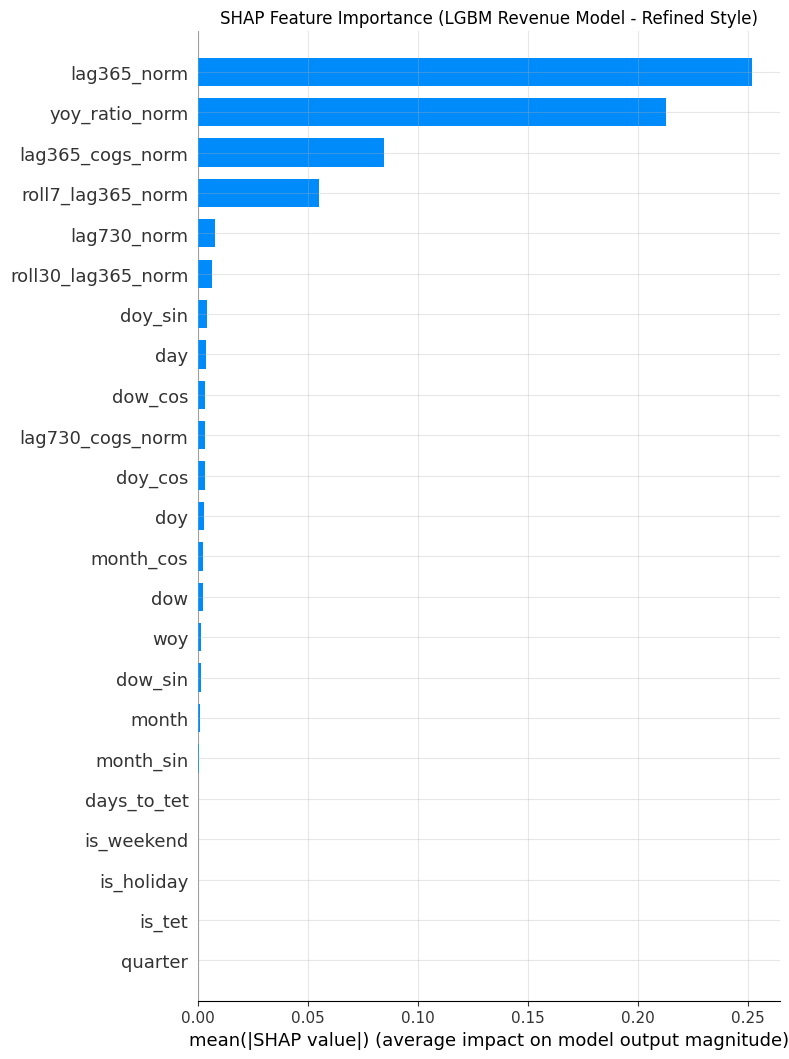

In [122]:
import shap
import matplotlib.pyplot as plt
explainer = shap.TreeExplainer(predictor_revenue)
shap_sample = history_pre_covid[PREDICTIVE_COLUMNS].sample(n=min(2000, len(history_pre_covid)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 9))
shap.summary_plot(shap_values, shap_sample, plot_type='bar', max_display=25, show=False)
plt.title('SHAP Feature Importance (LGBM Revenue Model - Refined Style)')
plt.tight_layout()
plt.show()

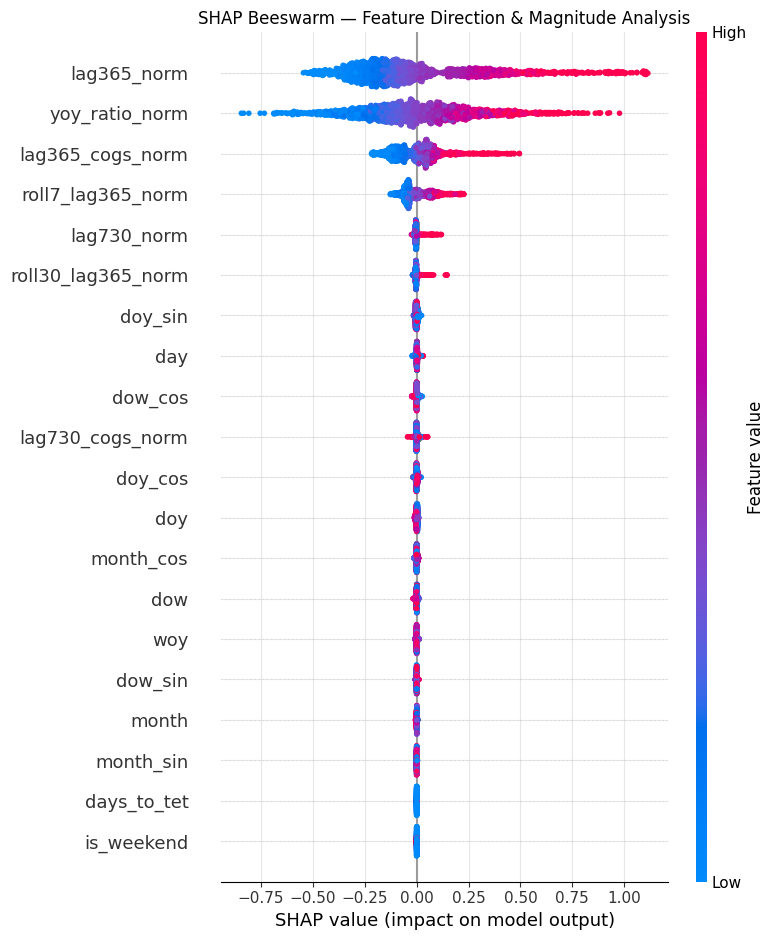

In [123]:
plt.figure(figsize=(10, 9))
shap.summary_plot(shap_values, shap_sample, max_display=20, show=False)
plt.title('SHAP Beeswarm — Feature Direction & Magnitude Analysis')
plt.tight_layout()
plt.show()